# ☕Coffee Quality Prediction Using RandomForest and Bagging Classifier

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Loading Dataset

In [2]:
df = pd.read_csv(r"C:\Users\diyap\OneDrive\Desktop\Start\Coffee Quality Prediction\arabica_data_cleaned.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'Species', 'Owner', 'Country.of.Origin', 'Farm.Name',
       'Lot.Number', 'Mill', 'ICO.Number', 'Company', 'Altitude', 'Region',
       'Producer', 'Number.of.Bags', 'Bag.Weight', 'In.Country.Partner',
       'Harvest.Year', 'Grading.Date', 'Owner.1', 'Variety',
       'Processing.Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
       'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points',
       'Total.Cup.Points', 'Moisture', 'Category.One.Defects', 'Quakers',
       'Color', 'Category.Two.Defects', 'Expiration', 'Certification.Body',
       'Certification.Address', 'Certification.Contact', 'unit_of_measurement',
       'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters'],
      dtype='object')

In [4]:
df = df[[
    "Aroma",
    "Flavor",
    "Aftertaste",
    "Acidity",
    "Body",
    "Balance",
    "Uniformity",
    "Clean.Cup",
    "Sweetness",
    "Cupper.Points",
    "Total.Cup.Points",
    "Moisture",
    "Category.One.Defects",
    "Category.Two.Defects",
    "Quakers"
]]

df.head()

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Category.Two.Defects,Quakers
0,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0,0.0
1,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,1,0.0
2,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0,0.0
3,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00,0.11,0,2,0.0
4,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83,0.12,0,2,0.0


In [5]:
df.isnull().sum()

Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Uniformity              0
Clean.Cup               0
Sweetness               0
Cupper.Points           0
Total.Cup.Points        0
Moisture                0
Category.One.Defects    0
Category.Two.Defects    0
Quakers                 1
dtype: int64

In [7]:
df["Quakers"] = df["Quakers"].fillna(df["Quakers"].mean())

In [8]:
df.isnull().sum()

Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Uniformity              0
Clean.Cup               0
Sweetness               0
Cupper.Points           0
Total.Cup.Points        0
Moisture                0
Category.One.Defects    0
Category.Two.Defects    0
Quakers                 0
dtype: int64

## Creating Quality Label

In [9]:
df["quality"] = df["Total.Cup.Points"].apply(
    lambda x: 1 if x >= 82 else 0
)

df["quality"].value_counts()

quality
1    815
0    496
Name: count, dtype: int64

## Number Of Values For Each Quality

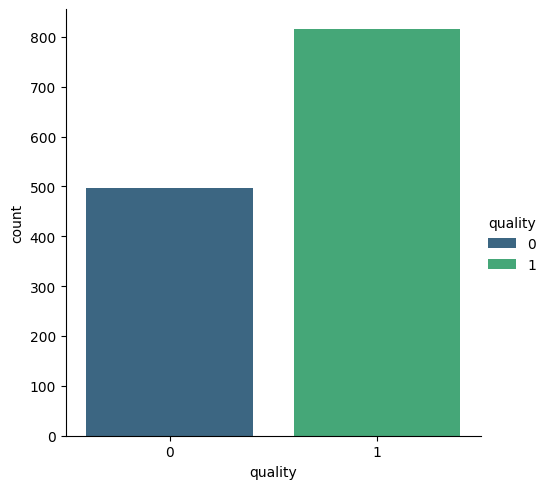

In [10]:
sns.catplot(
    x="quality",
    data=df,
    kind="count",
    hue="quality",
    palette="viridis"
)

plt.show()

## Aroma vs Quality

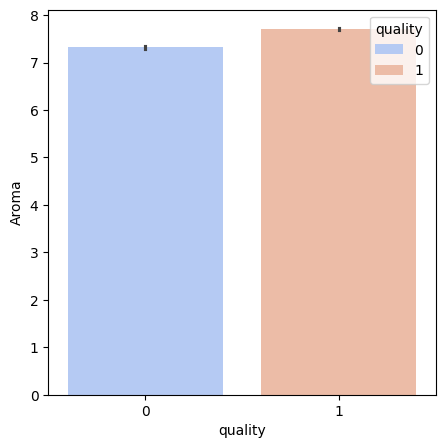

In [12]:
plt.figure(figsize=(5,5))

sns.barplot(
    x="quality",
    y="Aroma",
    data=df,
    palette="coolwarm",
    hue="quality"
)

plt.show()

## Flavor vs Quality

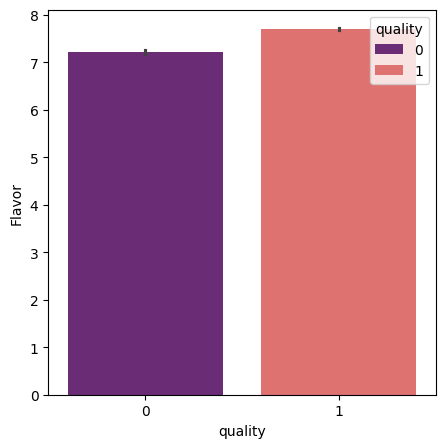

In [13]:
plt.figure(figsize=(5,5))

sns.barplot(
    x="quality",
    y="Flavor",
    data=df,
    palette="magma",
    hue="quality"
)

plt.show()

## Acidity vs Quality

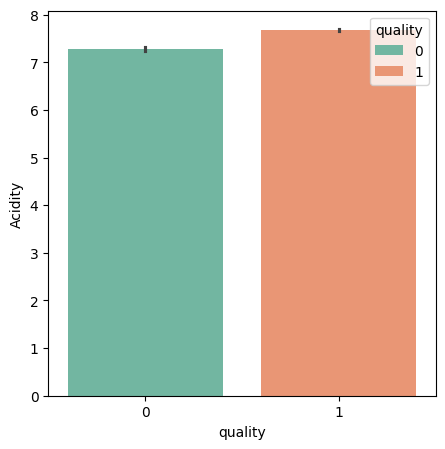

In [14]:
plt.figure(figsize=(5,5))

sns.barplot(
    x="quality",
    y="Acidity",
    data=df,
    palette="Set2",
    hue="quality"
)

plt.show()

## Body vs Quality

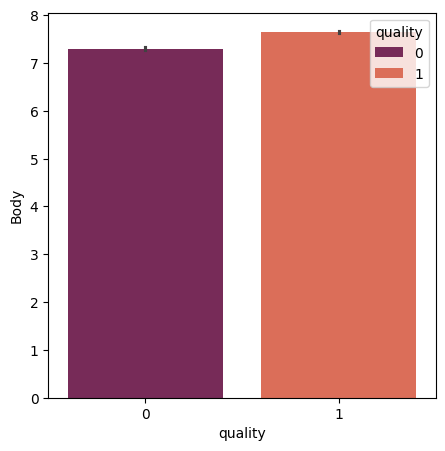

In [15]:
plt.figure(figsize=(5,5))

sns.barplot(
    x="quality",
    y="Body",
    data=df,
    palette="rocket",
    hue="quality"
)

plt.show()

## Balance vs Quality

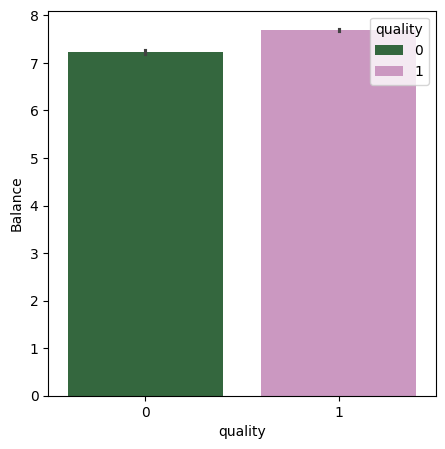

In [16]:
plt.figure(figsize=(5,5))

sns.barplot(
    x="quality",
    y="Balance",
    data=df,
    palette="cubehelix",
    hue="quality"
)

plt.show()

## Correlation Heatmap

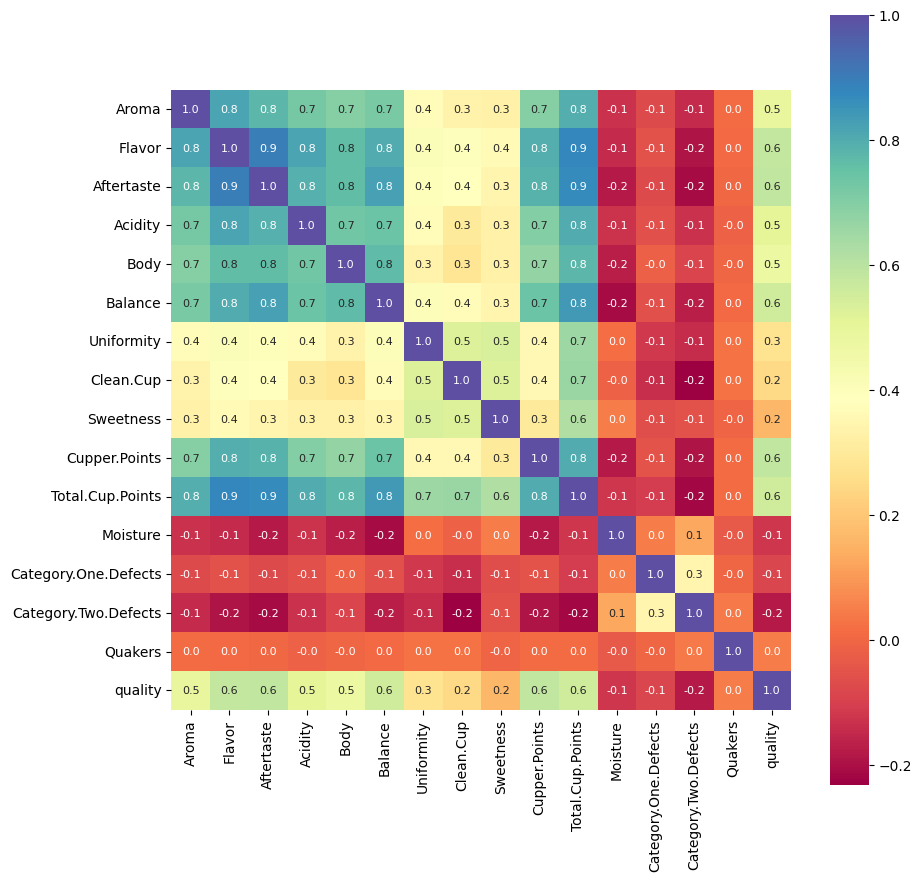

In [17]:
correlation = df.corr()

plt.figure(figsize=(10,10))

sns.heatmap(
    correlation,
    cbar=True,
    square=True,
    fmt=".1f",
    annot=True,
    annot_kws={"size":8},
    cmap="Spectral"
)

plt.show()

## Separating Features and Target

In [25]:
X = df.drop(["quality", "Total.Cup.Points"], axis=1)

y = df["quality"]

print(X.shape)
print(y.shape)

(1311, 14)
(1311,)


## Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(y.shape, y_train.shape, y_test.shape)

(1311,) (1048,) (263,)


## RandomForestClassifier

In [27]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

In [28]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

Accuracy: 0.9695817490494296
Confusion Matrix:
 [[ 93   2]
 [  6 162]]


## Confusion Matrix 

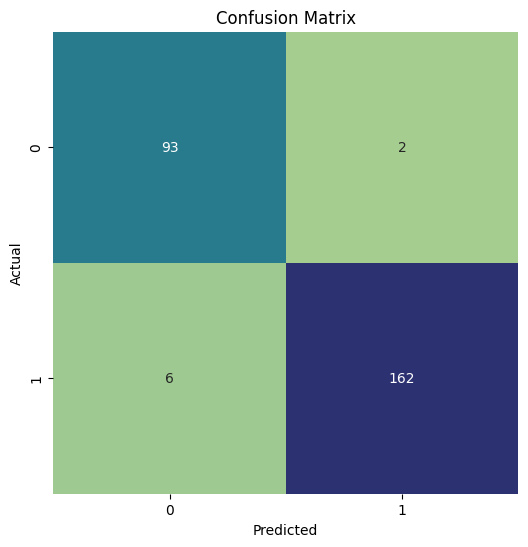

In [29]:
plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="crest",
    cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Classification Report

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        95
           1       0.99      0.96      0.98       168

    accuracy                           0.97       263
   macro avg       0.96      0.97      0.97       263
weighted avg       0.97      0.97      0.97       263



## Bagging Classifier 

In [31]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


## Bagging Evaluation

In [32]:
y_pred_bag = bag.predict(X_test)

bag_acc = accuracy_score(y_test, y_pred_bag)

print("Bagging Accuracy:", bag_acc)

cm_bag = confusion_matrix(y_test, y_pred_bag)

print("Confusion Matrix:\n", cm_bag)

Bagging Accuracy: 0.9581749049429658
Confusion Matrix:
 [[ 92   3]
 [  8 160]]


## Bagging Confusion Matrix 

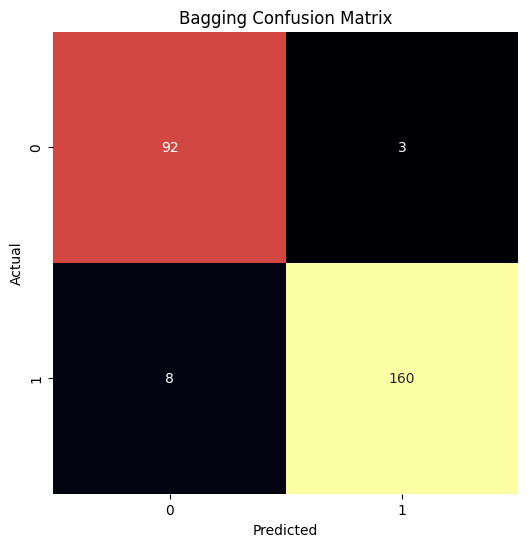

In [35]:
plt.figure(figsize=(6,6))

sns.heatmap(
    cm_bag,
    annot=True,
    fmt=".0f",
    cmap="inferno",
    cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Confusion Matrix")

plt.show()

## Bagging Classification Report

In [36]:
print(classification_report(y_test, y_pred_bag))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94        95
           1       0.98      0.95      0.97       168

    accuracy                           0.96       263
   macro avg       0.95      0.96      0.96       263
weighted avg       0.96      0.96      0.96       263



## Model Comparison

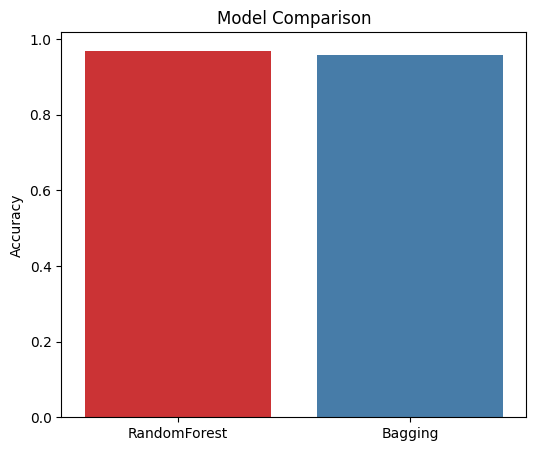

In [39]:
models = ["RandomForest", "Bagging"]

scores = [accuracy, bag_acc]

plt.figure(figsize=(6,5))

sns.barplot(
    x=models,
    y=scores,
    hue=models,
    palette="Set1",
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

## Feature Importance

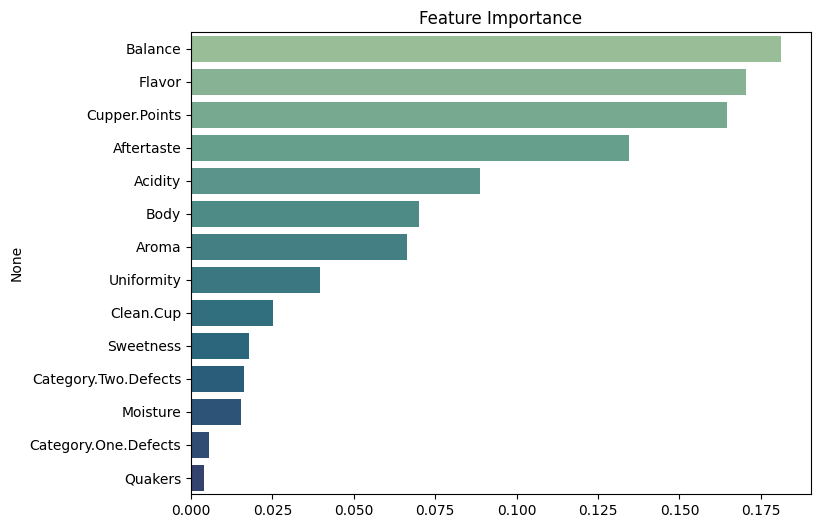

In [40]:
importances = rf.feature_importances_

features = X.columns

feat_imp = pd.Series(importances, index=features)

feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index,
    hue=feat_imp.index,
    palette="crest",
    legend=False
)

plt.title("Feature Importance")

plt.show()

## Building a Predictive System

In [44]:
input_data = {
    "Aroma": 8.5,
    "Flavor": 8.6,
    "Aftertaste": 8.4,
    "Acidity": 8.3,
    "Body": 8.4,
    "Balance": 8.5,
    "Uniformity": 10.0,
    "Clean.Cup": 10.0,
    "Sweetness": 10.0,
    "Cupper.Points": 8.5,
    "Moisture": 0.10,
    "Category.One.Defects": 0,
    "Category.Two.Defects": 0,
    "Quakers": 0
}

input_df = pd.DataFrame([input_data])

prediction = rf.predict(input_df)

print(prediction)

if prediction[0] == 1:
    print("Good Quality Coffee")
else:
    print("Bad Quality Coffee")

[1]
Good Quality Coffee
